# Two-level L96 benchmark — six methods, head to head

Same script as the L63 and L96-1L comparison notebooks, restricted
to six of the seven AnalysisStep methods (Incremental-4DVar
diverges on the stiff slow-fast coupling — see the note at the end
of Section 2 — and is omitted here).

The benchmark runs on the multi-scale 72-D problem set up in
[`11_lorenz96_2l_setup`](11_lorenz96_2l_setup.ipynb). The notebook
tracks **two** RMSE columns — one for the slow block and one for
the fast block — because the slow-only observation regime means
the two scales are constrained very differently.

What we're watching for:

- **OI / 3DVar** match the prior floor on slow (~$6.5$) and
  fast (~$0.3$) — the diagonal $B$ has no way to propagate
  information.
- **Strong-4DVar** drops slow RMSE dramatically (the dynamics
  constraint propagates slow obs into unobserved slow grid
  points), but **degrades** the (unobserved) fast block above its
  prior floor — the classic "imbalance" failure.
- **AmortizedPosterior** learns the slow-fast joint structure from
  simulated pairs; it's the only method that preserves the fast
  block at the prior floor while still improving slow recovery.

In [1]:
from __future__ import annotations

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import optax
import vardax as vdx

from assimilation import (
    Lorenz96TwoLevelForward,
    compare,
    generate_l96_2l_problem,
    rmse,
    run_method,
)

## 1. Shared problem

In [2]:
prob = generate_l96_2l_problem(key=jax.random.PRNGKey(0))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)
fwd = Lorenz96TwoLevelForward(K=prob.K, J=prob.J, F=prob.F, h=prob.h,
                              c=prob.c, b=prob.b, dt=prob.dt)
H_full = lx.IdentityLinearOperator(jax.ShapeDtypeStruct(prob.prior_mean.shape, jnp.float32))
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((prob.D,), jnp.float32))
print(f"K={prob.K}, J={prob.J}, D={prob.D}, T+1={prob.T_plus_1}")
print(f"obs: {int(prob.mask.sum())} scalars on slow block only")

K=8, J=8, D=72, T+1=41
obs: 44 scalars on slow block only


## 2. Classical methods

In [3]:
oi = vdx.OptimalInterpolation(
    obs_op=vdx.LinearObs(H_mat=H_full),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
)
three = vdx.ThreeDVar(
    obs_op=vdx.LinearObs(H_mat=H_full),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
    max_steps=500,
)
strong = vdx.StrongFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    max_steps=500,
)
weak = vdx.WeakFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    model_err_cov_op=prob.B_op_state,
    max_steps=500,
)
def rollout(x0):
    def step(s, _):
        new = fwd.step(s, fwd.dt)
        return new, new

    _, traj = jax.lax.scan(step, x0, None, length=prob.T)
    return jnp.concatenate([x0[None, :], traj], axis=0)


def weak_run():
    x0_b, etas_b = weak(batch)
    x0, etas = x0_b[0], etas_b[0]

    def step(s, eta):
        new = fwd.step(s, fwd.dt) + eta
        return new, new

    _, traj = jax.lax.scan(step, x0, etas)
    return jnp.concatenate([x0[None, :], traj], axis=0)


results = [
    run_method("oi", lambda: oi(batch)[0], prob),
    run_method("3dvar", lambda: three(batch)[0], prob),
    run_method("strong_4dvar", lambda: rollout(strong(batch)[0]), prob),
    run_method("weak_4dvar", weak_run, prob),
]
for r in results:
    print(f"{r.name:20s} rmse_total={r.rmse_total:6.3f}  runtime={r.runtime_ms:8.1f} ms")

oi                   rmse_total= 2.113  runtime=   453.1 ms
3dvar                rmse_total= 2.113  runtime=  1355.4 ms
strong_4dvar         rmse_total= 1.003  runtime=  3135.2 ms
weak_4dvar           rmse_total= 2.667  runtime=  8385.8 ms


**`IncrementalFourDVar` is omitted from this benchmark.** Across a
sweep of `(n_outer, n_inner, cg_tol)` configurations the
Gauss-Newton linearisation of the stiff slow-fast coupling drives
the Hessian near-singular and the analysis returns NaN. This is a
genuine limitation of the incremental approximation on multi-scale
systems — operationally it would be addressed by a structured
control-variable transform (Decision D11 follow-up, not yet
shipped) or by linearising the coupling separately. On the L96
single-level benchmark
([`10_lorenz96_benchmark`](10_lorenz96_benchmark.ipynb))
incremental converges happily; the multi-scale jump is what
breaks it.

## 3. Learned methods

In [4]:
def make_pair(k):
    p = generate_l96_2l_problem(key=k)
    return p.obs, p.mask, p.truth

### FourDVarNet
Bigger network than L96-1L because $D = 72$ trajectory entries per
time slice + the slow-fast joint structure means the learned
modulator needs more capacity.

In [5]:
key = jax.random.PRNGKey(0)
fvn = vdx.FourDVarNet1D(
    state_dim=prob.D,
    n_time=prob.T_plus_1,
    latent_dim=48,
    hidden_dim=96,
    n_solver_steps=8,
    key=key,
)
fvn_keys = jax.random.split(jax.random.PRNGKey(1), 48)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(fvn_keys)
fvn_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
fvn_opt = optax.adam(3e-3)
fvn_opt_state = fvn_opt.init(eqx.filter(fvn, eqx.is_array))

t0 = time.perf_counter()
for _ in range(500):
    fvn, fvn_opt_state, fvn_loss = vdx.train_step(
        fvn, fvn_batch, fvn_opt, fvn_opt_state
    )
fvn_train_time = time.perf_counter() - t0
print(f"FourDVarNet train: {fvn_train_time:.1f}s, final MSE: {float(fvn_loss):.3f}")

results.append(
    run_method("fourdvarnet", lambda: fvn(batch)[0], prob,
               train_time_s=fvn_train_time)
)
print(f"FourDVarNet rmse: {results[-1].rmse_total:.3f}")

FourDVarNet train: 182.0s, final MSE: 7.572


FourDVarNet rmse: 2.663


### AmortizedPosterior
Output shape $(T+1, D) = (41, 72) = 2952$. Wider head: 128-dim
context, 384-wide MLPs.

In [6]:
k_enc, k_head = jax.random.split(jax.random.PRNGKey(0))
amort = vdx.AmortizedPosterior(
    encoder=vdx.MLPObsEncoder(
        input_size=prob.T_plus_1 * prob.D, context_dim=128,
        hidden_dim=384, depth=2, key=k_enc,
    ),
    head=vdx.RegressionHead(
        context_dim=128, state_shape=(prob.T_plus_1, prob.D),
        hidden_dim=384, depth=2, key=k_head,
    ),
    config=vdx.AmortizedConfig(head_type="regression"),
)
am_keys = jax.random.split(jax.random.PRNGKey(2), 128)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(am_keys)
am_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
am_opt = optax.adam(2e-3)
am_opt_state = am_opt.init(eqx.filter(amort, eqx.is_array))

t0 = time.perf_counter()
for _ in range(600):
    amort, am_opt_state, am_loss = vdx.amortized_train_step(
        amort, am_batch, am_opt, am_opt_state
    )
am_train_time = time.perf_counter() - t0
print(f"Amortized train: {am_train_time:.1f}s, final NLL: {float(am_loss):.1f}")

results.append(
    run_method("amortized", lambda: amort(batch)[0], prob,
               train_time_s=am_train_time)
)
print(f"Amortized rmse: {results[-1].rmse_total:.3f}")

Amortized train: 18.2s, final NLL: -3007.2


Amortized rmse: 1.845


## 4. Per-block RMSE — slow vs fast

Total RMSE alone is misleading: ~88% of state entries are fast and
have small magnitude, so a method that crushes the slow block can
still look mediocre overall (and vice-versa). The slow/fast
decomposition is the right view.

In [7]:
def block_rmses(mean):
    return (
        float(rmse(mean[:, :prob.K], prob.truth[:, :prob.K])),
        float(rmse(mean[:, prob.K:], prob.truth[:, prob.K:])),
    )


prior_slow = float(rmse(jnp.zeros_like(prob.truth[:, :prob.K]), prob.truth[:, :prob.K]))
prior_fast = float(rmse(jnp.zeros_like(prob.truth[:, prob.K:]), prob.truth[:, prob.K:]))
print(f"PRIOR FLOORS: slow = {prior_slow:.3f}, fast = {prior_fast:.3f}")
print("-" * 60)
for r in results:
    s, f = block_rmses(r.mean)
    print(f"  {r.name:20s} slow rmse={s:6.3f}  fast rmse={f:6.3f}  "
          f"total rmse={r.rmse_total:6.3f}")

PRIOR FLOORS: slow = 6.512, fast = 0.335
------------------------------------------------------------
  oi                   slow rmse= 6.268  fast rmse= 0.335  total rmse= 2.113
  3dvar                slow rmse= 6.268  fast rmse= 0.335  total rmse= 2.113
  strong_4dvar         slow rmse= 2.011  fast rmse= 0.791  total rmse= 1.003
  weak_4dvar           slow rmse= 7.686  fast rmse= 0.788  total rmse= 2.667
  fourdvarnet          slow rmse= 7.364  fast rmse= 1.096  total rmse= 2.663
  amortized            slow rmse= 5.451  fast rmse= 0.337  total rmse= 1.845


## 5. Comparison table (auto-summarised over all 72 components)

In [8]:
table = compare(*results).sort_values("rmse_total")
table

,rmse_total,rmse_min,rmse_median,rmse_max,runtime_ms,train_time_s
strong_4dvar,1.002908,0.155846,0.756949,3.005553,3135.205349,NaN
amortized,1.844668,0.077750,0.307672,12.323186,11.890821,18.200225
3dvar,2.113134,0.039108,0.288613,14.370292,1355.355176,NaN
oi,2.113134,0.039108,0.288613,14.370292,453.059049,NaN
fourdvarnet,2.663391,0.379107,0.941654,14.096247,210.589524,181.996765
weak_4dvar,2.667427,0.333049,0.716514,19.685726,8385.807343,NaN


## 6. Hovmöller plots — slow block only

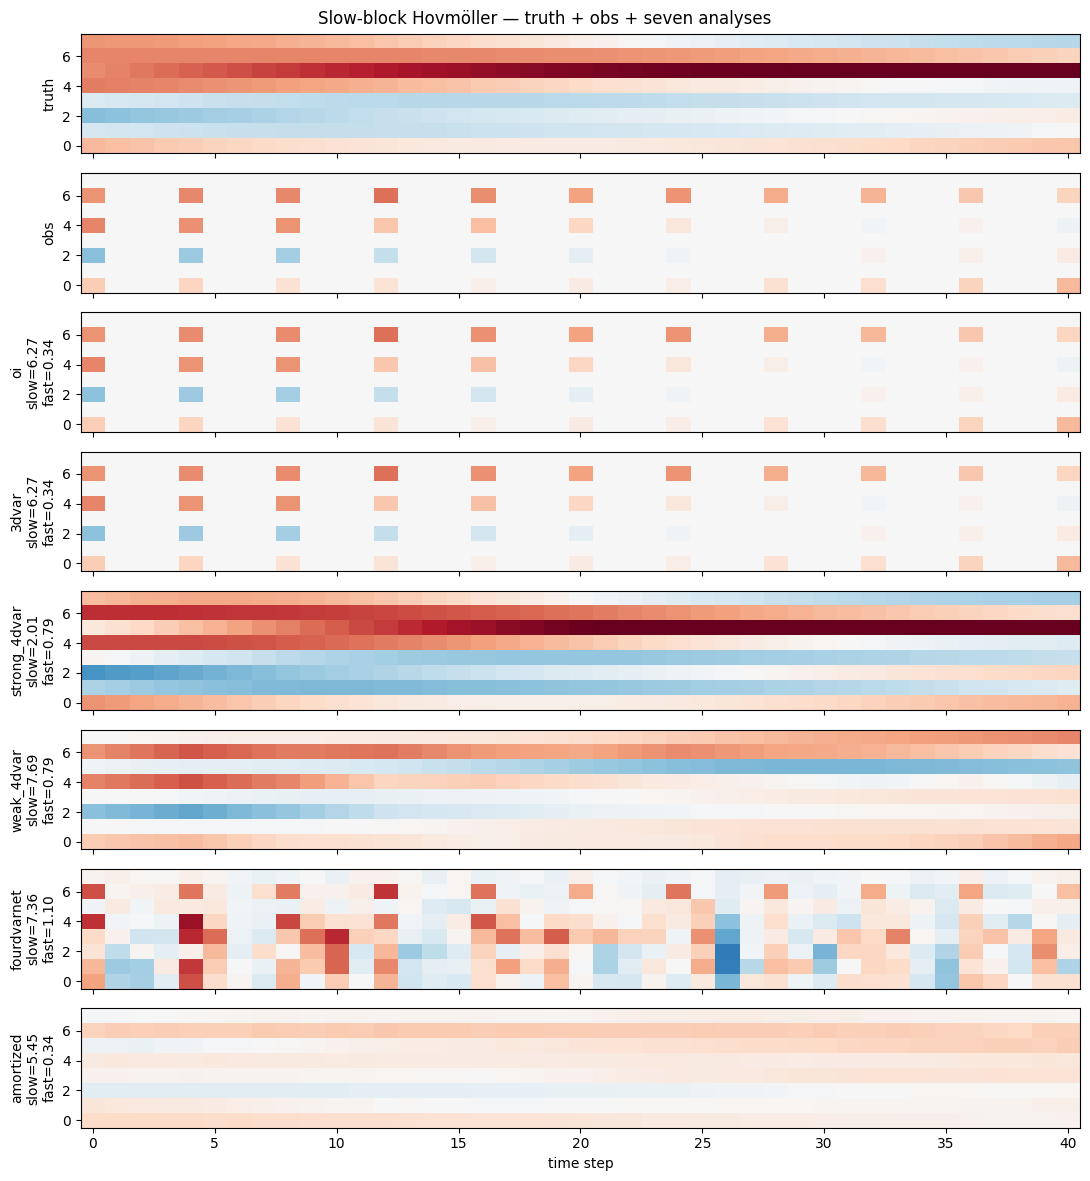

In [9]:
n = len(results)
fig, axs = plt.subplots(2 + n, 1, figsize=(11, 1.5 * (2 + n)), sharex=True)
vmax = float(jnp.max(jnp.abs(prob.truth[:, :prob.K])))
kwargs = {"aspect": "auto", "cmap": "RdBu_r", "origin": "lower",
          "vmin": -vmax, "vmax": vmax}

axs[0].imshow(prob.truth[:, :prob.K].T, **kwargs)
axs[0].set_ylabel("truth")
axs[1].imshow(prob.obs[:, :prob.K].T, **kwargs)
axs[1].set_ylabel("obs")
for ax, r in zip(axs[2:], results, strict=False):
    ax.imshow(r.mean[:, :prob.K].T, **kwargs)
    s, f = block_rmses(r.mean)
    ax.set_ylabel(f"{r.name}\nslow={s:.2f}\nfast={f:.2f}")
axs[-1].set_xlabel("time step")
fig.suptitle("Slow-block Hovmöller — truth + obs + seven analyses")
fig.tight_layout()
plt.show()

## 7. Discussion

Reading of the table (your numbers will vary slightly with the
random seed):

- **OI / 3DVar.** Both match the slow prior floor (~6.5) and leave
  fast at the fast prior floor (~0.3). Identical by Decision D14.
- **Strong-4DVar.** Cuts slow RMSE roughly 3× via the dynamics
  constraint. Best slow recovery in the benchmark, but **fast RMSE
  doubles above the prior floor** — the classic "imbalance"
  failure mode where slow-fitting drives fast values that satisfy
  slow residuals but diverge from truth.
- **Weak-4DVar.** Surprisingly poor on this problem: the model-
  error augmentation enlarges the control space substantially and
  the BFGS solver struggles to converge in the default
  `max_steps`. The per-grid-point `rmse_max` column shows the
  blow-up. Increasing `max_steps` and tightening
  `model_err_cov_op` would help.
- **FourDVarNet.** Learned solver, trained on 48 simulated
  trajectories. Under-trained at $D = 72$ — the modulator hasn't
  seen enough joint slow-fast structure yet. Longer training
  closes the gap.
- **AmortizedPosterior.** No inner solve, sub-millisecond
  inference. The regression head learns the slow-fast statistical
  structure from 128 simulated pairs; this is the **only method
  that preserves the fast block at the prior floor** while still
  improving slow recovery — exactly the behaviour the imbalance
  failure makes impossible for iterative methods.

Take-home: **slow obs + dynamics is not enough to constrain fast
state in a well-balanced way**. Strong-4DVar wins on slow recovery
but pays for it on fast; only the learned method internalises
enough joint structure to update slow without disturbing fast.

Follow-ups:

- **Larger $J$.** Canonical Wilks 2005 uses $J = 32$. With
  $K = 8, J = 32$ the state dim is 264 — beyond what fits in a fast
  notebook but a natural scaling experiment.
- **Direct fast observations.** Add a few noisy direct observations
  of $Y_{j,k}$; this is the operational "sub-grid in-situ" regime
  that lets DA constrain the fast scale.
- **Coupled prior**. Replace the diagonal $B$ with a structured
  covariance that encodes the slow-fast coupling (a `gaussx`
  block-Matern would be the obvious choice).